In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import h5py
import os
from datetime import datetime

['hod06653_aug00000.h5', 'hod06655_aug00000.h5', 'hod06651_aug00000.h5', 'hod06652_aug00000.h5', 'hod06654_aug00000.h5']


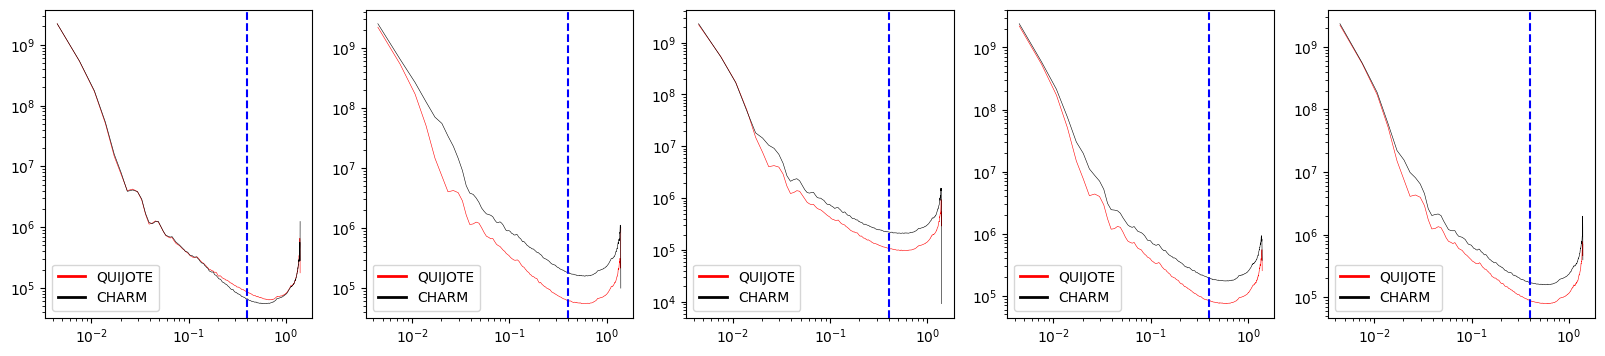

In [66]:
sim_dir = '/anvil/scratch/x-mho1/cmass-ili'
# sim_dir = '/anvil/scratch/x-dbartlett/cmass'
lhid = 665

quijote_dir = os.path.join(sim_dir, 'quijote/nbody_nonoise/L1000-N128', str(lhid), 'diag/simbig_lightcone/')
quijote_dir = os.path.join(sim_dir, 'quijote/varnoise/L1000-N128', str(lhid), 'diag/simbig_lightcone/')
charm_dir = os.path.join(sim_dir, 'quijotelike/fastpm_recnoise/L1000-N128', str(lhid), 'diag/simbig_lightcone/')

date_cutoff = datetime(2025, 7, 1)
cutoff_timestamp = date_cutoff.timestamp()

# Load the Pks
data = {}
sims = None
for dirname in [quijote_dir, charm_dir]:
    run_name = dirname
    data[run_name] = {'Pk':[], 'k':[]}
    if sims is None:
        sims = os.listdir(dirname)
        print(sims)
    for sim in sims:
        file_path = os.path.join(dirname, sim)
        file_mtime = os.path.getmtime(file_path)
        pick_file = True
        # if 'quijotelike' in dirname:
            # pick_file = file_mtime > cutoff_timestamp
        if pick_file:
            with h5py.File(file_path, 'r') as f:
                data[run_name]['Pk'].append(f['Pk'][:])
                data[run_name]['k'].append(f['Pk_k3D'][:])

fig, axs = plt.subplots(1, len(sims), figsize=(20,4))
for i in range(len(sims)):
    ax = axs[i]
    custom_lines = []
    for key, c in zip(data.keys(), ['r', 'k']):
        k = data[key]['k'][i]
        p = data[key]['Pk'][i]
        ax.loglog(k, p[:,0], color=c, lw=0.4)
        # Add label
        lab = 'CHARM' if 'quijotelike' in key else 'QUIJOTE'
        custom_lines.append(Line2D([0], [0], color=c, lw=2, label=lab))
    ax.legend(handles=custom_lines)
    ax.axvline(0.4, color='blue', ls='--')

In [70]:
with h5py.File('/anvil/scratch/x-dbartlett/cmass/abacuslike/fastpm/L2000-N256/665/diag/halos.h5', 'r') as f:
    print(f['0.586220'].keys())

<KeysViewHDF5 ['Pk', 'Pk_k3D', 'mass_bins', 'mass_hist', 'zPk', 'zPk_k3D']>


# Abacus halos

Fiducial is sigma=0.0, noise_uniform=True


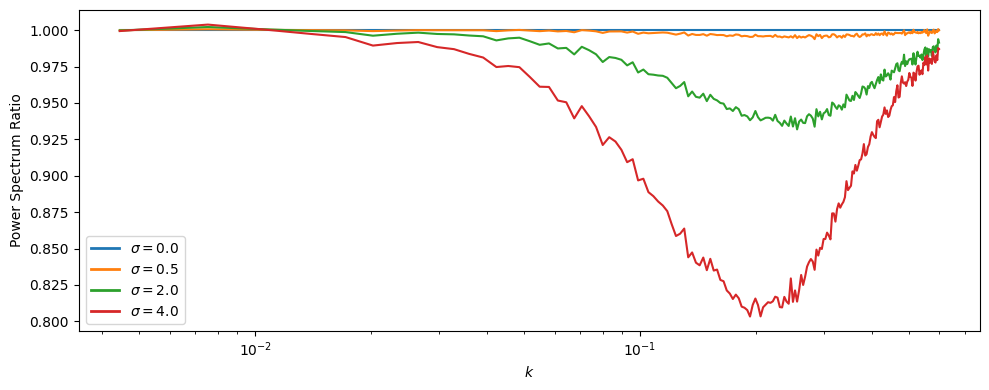

In [3]:
dirname = '/anvil/scratch/x-dbartlett/cmass/abacuslike/fastpm/L2000-N256/665/diag/'

# Get all sigma
sigmas = os.listdir(dirname)
start = 'halos_sigma_'
sigmas = [sig[len(start):] for sig in sigmas if sig[-3:] == '.h5' and sig.startswith(start)]
sigmas = list(set([sig[:sig.index('_')] for sig in sigmas if '_' in sig]))
sigmas.sort()

a = '0.586220'
# sigmas = [0.0, 0.5, 1.0, 2.0]
# sigmas = [0.0]

kmax = 0.6

fig, ax = plt.subplots(1, 1, figsize=(10,4))
fid = None
for noise_uniform in [True]:
    for i, sig in enumerate(sigmas):
        fname = os.path.join(dirname, f'{start}{sig}_noise_uniform_{noise_uniform}.h5')
        with h5py.File(fname, 'r') as f:
            k = f[a]['Pk_k3D'][:]
            Pk = f[a]['Pk'][:]
            Pk = Pk[:,0]
        if noise_uniform:
            ls = '-'
        else:
            ls ='--'
        if fid is None:
            fid = Pk.copy()
            print(f'Fiducial is sigma={sig}, noise_uniform={noise_uniform}')
        
        m = k <= kmax
        
        # ax.loglog(k, Pk, ls=ls)#, color=f'C{i}')
        ax.semilogx(k[m], Pk[m] / fid[m], ls=ls, color=f'C{i}')
        
custom_lines = [Line2D([0], [0], color=f'C{i}', lw=2, label=r'$\sigma=%.1f$'%float(sigmas[i])) for i in range(len(sigmas))]
# custom_lines.append(Line2D([0], [0], color='k', ls='-', lw=2, label='Uniform = True'))
# custom_lines.append(Line2D([0], [0], color='k', ls='--', lw=2, label='Uniform = False'))
ax.legend(handles=custom_lines)
ax.set_xlabel(r'$k$')
ax.set_ylabel('Power Spectrum Ratio')
fig.tight_layout()
fig.savefig('abacus_noise_halos_box.png', bbox_inches='tight')
